# Predicting California house prices with MindSpore v2

_This is the revised, improved version of the original project on GitCode: [donaldsebleung/california-housing-mindspore](https://gitcode.com/donaldsebleung/california-housing-mindspore)_

[MindSpore](https://www.mindspore.cn/) is an open source deep learning framework lead by [Huawei](https://www.huawei.com/en/) and the MindSpore community. It is optimized for performing model training and inference tasks on Huawei's [Ascend](https://www.hiascend.com/) series processors \(NPUs\), though it supports NVIDIA GPUs and CPU-only environments as well. It provides a compelling alternative to [PyTorch](https://pytorch.org/), the leading open source deep learning framework under the [Linux Foundation](https://www.linuxfoundation.org/). Furthermore, it provides utility classes and functions compatible with a subset of PyTorch to ease the migration of training and inference pipelines from PyTorch to MindSpore, which is out of scope for this article.

In this lab, we will use MindSpore for training a simple linear regression model consisting of a single fully connected layer to predict house prices in California. The dataset we will be using is the California housing dataset which we'll fetch using scikit-learn's [`sklearn.datasets.fetch_california_housing`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) function.

## Prerequisites and suggested reading

The first 3 chapters of [Dive into Deep Learning](https://d2l.ai/), also known as D2L. It covers the background knowledge on introductory probability, statistics and linear algebra, as well as data pre-processing, transformation methods and linear regression techniques required to understand the steps performed in this lab.

## Software environment and dependencies

The instructions in this lab were tested on the [OrangePi AIpro \(20T\)](http://www.orangepi.org/html/hardWare/computerAndMicrocontrollers/details/Orange-Pi-AIpro%2820t%29.html) development board. It should work in a CPU-only environment as well with minimal configuration - simply specify the `NOTEBOOK_USE_CPU=1` environment variable. While it may work in NVIDIA GPU environments with few modifications by specifying the `NOTEBOOK_USE_GPU=1` environment variable, this has not been explicitly tested.

The software versions listed below which can be found in the provided `requirements.txt` as well.

1. Python 3.12
1. MindSpore 2.8.0
1. [CANN](https://www.hiascend.com/en/cann) 8.5.0 - only on Ascend platform
1. [Matplotlib](https://matplotlib.org/) 3.10.8
1. [scikit-learn](https://scikit-learn.org/stable/) 1.8.0

In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Initializing and checking MindSpore

Let's initialize MindSpore based on our hardware platform and verify that it is correctly installed.

In [2]:
import os

NOTEBOOK_USE_ASCEND = os.getenv('NOTEBOOK_USE_ASCEND', '0')
NOTEBOOK_USE_GPU = os.getenv('NOTEBOOK_USE_GPU', '0')
NOTEBOOK_USE_CPU = os.getenv('NOTEBOOK_USE_CPU', '0')
NOTEBOOK_CI_MODE = os.getenv('NOTEBOOK_CI_MODE', '0')

In [3]:
import mindspore

platform = 'Ascend'
if NOTEBOOK_USE_ASCEND == '1':
    platform = 'Ascend'
elif NOTEBOOK_USE_GPU == '1':
    platform = 'GPU'
elif NOTEBOOK_USE_CPU == '1' or NOTEBOOK_CI_MODE == '1':
    platform = 'CPU'
else:
    platform = 'Ascend'

mindspore.set_device(device_target=platform)
mindspore.run_check()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


Warnings can be safely ignored as long as no `[CRITICAL]` or `[ERROR]` messages appear, in which case check out the [Ascend forum](https://www.hiascend.com/forum/). If you see the below output, it means MindSpore 2.8.0 is correctly installed.

```text
MindSpore version: 2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!
```

## Loading and transforming the data

Let's fetch the California housing dataset with scikit-learn's `fetch_california_housing`. We'll convert the target to have shape `(20640, 1)`, to avoid issues with our linear regression algorithm due to broadcasting.

In [4]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X = housing.data
y = housing.target.reshape(-1, 1)
X.shape, y.shape

((20640, 8), (20640, 1))

Split the dataset into training and validation sets. We'll use an $80:20$ ratio which is common in many machine learning applications.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16512, 8), (4128, 8), (16512, 1), (4128, 1))

Let's inspect the first sample in our training set. Notice that all features and labels are purely numeric, floating point values - a perfect example of using linear regression.

In [6]:
X_train[0], y_train[0]

(array([   4.6       ,   24.        ,   13.10416667,    2.25      ,
         235.        ,    2.44791667,   38.92      , -119.94      ]),
 array([1.368]))

Verify that our data is clean with no `NaN` values.

In [7]:
import numpy as np

np.any(np.isnan(X).ravel()), np.any(np.isnan(y).ravel())

(False, False)

Great - none of our samples contain `NaN`s! Let's compute the mean and standard deviation of the labels in our training set.

In [8]:
y_train.mean(), y_train.std()

(2.065580750968992, 1.1444034792656754)

The scikit-learn documentation on [real-world datasets](https://scikit-learn.org/stable/datasets/real_world.html) states that the house prices are given as multiples of USD\\$100,000 so the label values range from $0.15$ through $5.0$. Nevertheless, it's a good idea to transform the labels through the 2-step process described below to make the data more Gaussian and centered, which should help our linear regression model produce more accurate results.

1. Compute $\log(1 + y_i)$ for each label $y_i$. The additional unit translation within the logarithm avoids issues with zero values since $\log 0$ is undefined, even though we don't expect any of our housing prices to be $0$
1. Apply the `StandardScaler` to the results in \(1\) to normalize the distribution to have zero mean $\mu = 0$ and unit variance $\sigma^2 = 1$

We'll achieve this through a custom scaler class `HousingPriceScaler` which inherits the following base classes in scikit-learn.

1. [`sklearn.base.BaseEstimator`](https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html): base class for all estimators in scikit-learn
1. [`sklearn.base.TransformerMixin`](https://scikit-learn.org/stable/modules/generated/sklearn.base.TransformerMixin.html): base class for data transformation in scikit-learn

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

class HousingPriceScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.scaler = StandardScaler()

    def fit(self, y):
        y_log1p = np.log1p(y)
        print(f'After log1p, before scaling: mean = {y_log1p.mean():.4f}, stddev = {y_log1p.std():.4f}')
        self.scaler.fit(y_log1p)
        return self

    def transform(self, y):
        y_log1p = np.log1p(y)
        y_scaled = self.scaler.transform(y_log1p)
        return y_scaled

    def inverse_transform(self, y_scaled):
        y_log1p = self.scaler.inverse_transform(y_scaled)
        y = np.expm1(y_log1p)
        return y

scaler = HousingPriceScaler()
scaler

HousingPriceScaler()

Before scaling the labels, let's scale the features as well. Unlike the labels which should be transformed via the 2-step process described above for optimal linear regression behavior, it suffices to normalize our features directly with [`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). This makes our scaled features have mean $\mu = 0$ and standard deviation $\sigma = 1$.

In [10]:
features_scaler = StandardScaler()
X_train_scaled = features_scaler.fit_transform(X_train)
X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0)
X_train_scaled_mean = X_train_scaled.mean(axis=0)
X_train_scaled_std = X_train_scaled.std(axis=0)
print(f'Before scaling: mean = {np.char.mod("%.4f", X_train_mean)}, stddev = {np.char.mod("%.4f", X_train_std)}')
print(f'After scaling: mean = {np.char.mod("%.4f", X_train_scaled_mean)}, stddev = {np.char.mod("%.4f", X_train_scaled_std)}')

X_test_scaled = features_scaler.transform(X_test)

Before scaling: mean = ['3.8585' '28.6504' '5.4089' '1.0934' '1434.3084' '3.1055' '35.6225'
 '-119.5605'], stddev = ['1.8732' '12.6085' '2.0784' '0.3725' '1150.1508' '11.5869' '2.1303'
 '1.9983']
After scaling: mean = ['-0.0000' '-0.0000' '-0.0000' '-0.0000' '-0.0000' '0.0000' '-0.0000'
 '-0.0000'], stddev = ['1.0000' '1.0000' '1.0000' '1.0000' '1.0000' '1.0000' '1.0000' '1.0000']


Now transform the labels in our training set with our custom scaler and observe the transformed labels are also centered with mean $\mu = 0$ and standard deviation $\sigma = 1$.

In [11]:
y_train_scaled = scaler.fit_transform(y_train)
print(f'Before scaling: mean = {y_train.mean():.4f}, stddev = {y_train.std():.4f}')
print(f'After scaling: mean = {y_train_scaled.mean():.4f}, stddev = {y_train_scaled.std():.4f}')

y_test_scaled = scaler.transform(y_test)

After log1p, before scaling: mean = 1.0561, stddev = 0.3536
Before scaling: mean = 2.0656, stddev = 1.1444
After scaling: mean = 0.0000, stddev = 1.0000


With our training labels appropriately scaled, it's time to define and train our neural network!

## Defining and training our linear regression model

Let's define a simple neural network with exactly 1 fully connected layer. The fully connected layer has 8 input channels and 1 output channel which corresponds to the number of features and labels in our dataset respectively.

With MindSpore, we do this by defining our own class inheriting from [`mindspore.nn.Cell`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/nn/mindspore.nn.Cell.html) and implement the `construct` method. Our fully connected layer is given by [`mindspore.nn.Dense`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/nn/mindspore.nn.Dense.html).

Let's also define our class to accept the following optional parameters.

1. `lr`: the learning rate of our model. Defaults to `0.01` if not specified
1. `wd`: the weight decay factor $\lambda$. Defaults to `0.0` if not specified

Note that we must use 16-bit floating point values defined as `float16` in [`mindspore.dtype`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/mindspore/mindspore.dtype.html). This is because matrix-vector and matrix-matrix multiplication is defined only for 16-bit floats with the CANN kernels library for the Ascend 310B1 NPU chip included with the OrangePi AIpro \(20T\) development board. This will reduce the precision of our model which is necessary and sufficient for our use case.

In [12]:
import mindspore.nn as nn
from mindspore import dtype as mstype

class MyModel(nn.Cell):
    def __init__(self, lr=0.01, wd=0.0):
        super().__init__()
        self.lr = lr
        self.wd = wd
        self.dense1 = nn.Dense(8, 1, dtype=mstype.float16)

    def construct(self, X):
        y_hat = self.dense1(X)
        return y_hat

model = MyModel(lr=0.03, wd=0.0)
model

MyModel(
  (dense1): Dense(input_channels=8, output_channels=1, has_bias=True)
)

Use the mean squared error \(MSE\) for our loss function, predefined in MindSpore with [`mindspore.nn.MSELoss`](https://www.mindspore.cn/docs/api/en/r2.8.0/api_python/nn/mindspore.nn.MSELoss.html).

In [13]:
loss_fn = nn.MSELoss()
loss_fn

MSELoss()

Use minibatch stochaistic gradient descent \(SGD\) for our optimizer, predefined in MindSpore with [`mindspore.nn.SGD`](https://www.mindspore.cn/docs/api/en/r2.8.0/api_python/nn/mindspore.nn.SGD.html). Pass in the learning rate and weight decay factor from our model via the `learning_rate` and `weight_decay` arguments, respectively.

In [14]:
optimizer = nn.SGD(params=model.trainable_params(),
                   learning_rate=model.lr,
                   weight_decay=model.wd)
optimizer

SGD()

Now define our forward and gradient functions. [`mindspore.value_and_grad`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/mindspore/mindspore.value_and_grad.html) accepts the following parameters.

1. `fn`: our forward function. It takes the features `X` and labels `y` as arguments and returns a tuple of `(loss, prediction)`
1. `grad_position`: set it to `None` and differentiate based on the model weights instead
1. `weights`: pass in the model weights available through our optimizer as `optimizer.parameters`
1. `has_aux`: set to `True` so it returns the gradient based on just the first argument `loss`

In [15]:
def forward_fn(X, y):
    y_hat = model(X)
    loss = loss_fn(y_hat, y)
    return loss, y_hat

grad_fn = mindspore.value_and_grad(fn=forward_fn,
                                   grad_position=None,
                                   weights=optimizer.parameters,
                                   has_aux=True)

Define our training step and training epoch. Each step we take a batch of a certain fixed size, usually a power of 2, e.g. $2^9=512$. 1 full pass on our training data is known as an _epoch_.

In [16]:
def train_step(X, y):
    (loss, _), grads = grad_fn(X, y)
    optimizer(grads)
    return loss

def train_epoch(dataset, epoch=0):
    model.set_train()
    print(f'Epoch {epoch} start')
    batch_total = dataset.get_dataset_size()
    training_losses = []
    for batch_idx, (X_batch, y_batch) in enumerate(dataset.create_tuple_iterator()):
        loss = train_step(X_batch, y_batch)
        print(f'Training loss (scaled): {loss.asnumpy():.4f} [{batch_idx}/{batch_total}]')
        training_losses.append(loss)
    print(f'Epoch {epoch} end')
    return training_losses

At the end of each epoch, let's also validate our model against the validation set. Recall that our model was trained on features normalized by `StandardScaler`, plus labels that have undergone the 2-step transformation described in an earlier section. It will return predictions which are similarly transformed. We can undo these transformations with the `inverse_transform` method of our scaler class, which gives us the predicted house prices in multiples of USD\\$100,000.

In [17]:
def validate_epoch(epoch=0):
    model.set_train(False)
    y_hat_scaled = model(mindspore.Tensor(X_test_scaled.astype(np.float16))).asnumpy()
    y_hat = scaler.inverse_transform(y_hat_scaled)
    validation_loss_scaled = loss_fn(mindspore.Tensor(y_hat_scaled), mindspore.Tensor(y_test_scaled))
    validation_loss = loss_fn(mindspore.Tensor(y_hat), mindspore.Tensor(y_test))
    print(f'Validation loss at epoch {epoch} (scaled): {validation_loss_scaled.asnumpy():.4f}')
    print(f'Validation loss at epoch {epoch}: {validation_loss.asnumpy():.4f}')
    return validation_loss_scaled

Convert our dataset to [`mindspore.dataset.NumpySlicesDataset`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/dataset/mindspore.dataset.NumpySlicesDataset.html) and feed it to our model in batches of $2^9=512$ samples per batch. We saw some of its included methods in the `train_epoch` function.

1. `get_dataset_size`: get the total number of batches in the dataset
1. `create_tuple_iterator`: convert the dataset into an iterator of tuples in the form `(batch_idx, (X_batch, y_batch))`

In [18]:
import mindspore.dataset as ds
import mindspore.ops as ops

train_ds = ds.NumpySlicesDataset(data=(X_train_scaled.astype(np.float16), y_train_scaled.astype(np.float16)),
                                 column_names=['features', 'labels'])
train_ds = train_ds.batch(batch_size=512)
epochs = 15
training_losses_scaled = []
validation_losses_scaled = []

for epoch_idx in range(epochs):
    training_losses_scaled.extend(train_epoch(train_ds, epoch=epoch_idx))
    validation_losses_scaled.append(validate_epoch(epoch=epoch_idx))

training_losses_scaled = ops.cast(ops.stack(training_losses_scaled, axis=0), dtype=mstype.float64)
validation_losses_scaled = ops.stack(validation_losses_scaled, axis=0)
training_losses_scaled.shape, validation_losses_scaled.shape

Epoch 0 start


/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/c

.Training loss (scaled): 1.5547 [0/33]
Training loss (scaled): 1.1748 [1/33]
Training loss (scaled): 1.1318 [2/33]
Training loss (scaled): 1.1299 [3/33]
Training loss (scaled): 1.0361 [4/33]
Training loss (scaled): 0.8628 [5/33]
Training loss (scaled): 0.8569 [6/33]
Training loss (scaled): 0.7734 [7/33]
Training loss (scaled): 0.7485 [8/33]
Training loss (scaled): 0.7378 [9/33]
Training loss (scaled): 0.6978 [10/33]
Training loss (scaled): 0.6807 [11/33]
Training loss (scaled): 0.6455 [12/33]
Training loss (scaled): 0.5977 [13/33]
Training loss (scaled): 0.6499 [14/33]
Training loss (scaled): 0.5522 [15/33]
Training loss (scaled): 0.6528 [16/33]
Training loss (scaled): 0.5889 [17/33]
Training loss (scaled): 0.5229 [18/33]
Training loss (scaled): 0.5688 [19/33]
Training loss (scaled): 0.4700 [20/33]
Training loss (scaled): 0.5098 [21/33]
Training loss (scaled): 0.5337 [22/33]
Training loss (scaled): 0.4756 [23/33]
Training loss (scaled): 0.5083 [24/33]
Training loss (scaled): 0.5239 [25

((495,), (15,))

Plot the scaled training vs. validation loss. Our model performs remarkably well on both seen and unseen inputs!

.

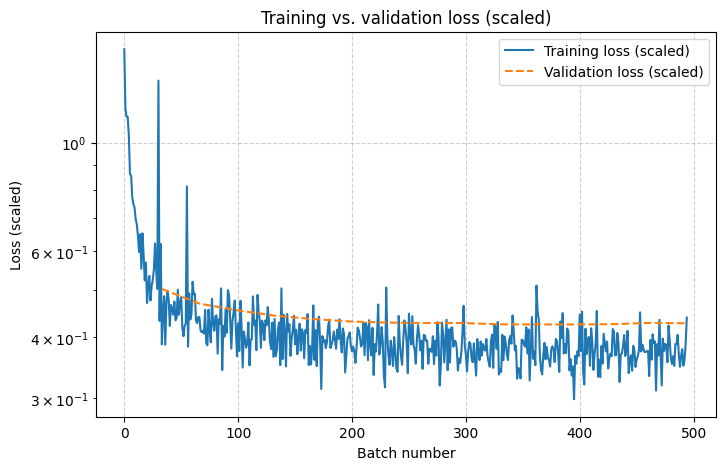

In [19]:
import matplotlib.pyplot as plt

batch_total = training_losses_scaled.size
epoch_total = validation_losses_scaled.size
batches_per_epoch = batch_total // epoch_total
batch_x = np.arange(batch_total)
epoch_x = np.arange(epoch_total) * batches_per_epoch + batches_per_epoch
training_losses_y = training_losses_scaled.asnumpy()
validation_losses_y = validation_losses_scaled.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(batch_x, training_losses_y, label='Training loss (scaled)', linestyle='-')
plt.plot(epoch_x, validation_losses_y, label='Validation loss (scaled)', linestyle='--')

plt.title('Training vs. validation loss (scaled)')
plt.xlabel('Batch number')
plt.ylabel('Loss (scaled)')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

## Predicting the house price on a validation sample

Let's take a sample from the validation set and use our model to predict the house price. We'll see how it compares to the actual price and how much it differs.

Recall that:

1. The features are normalized to have mean $\mu = 0$ and $\sigma = 1$ with scikit-learn's `StandardScaler`
1. The labels are transformed by the 2-step process below.
    1. Compute $\log (1 + y_i)$ for each label $y_i$
    1. Normalize the result in \(a\) with `StandardScaler`
1. The _original_ labels are expressed as multiples of USD\\$100,000

In [20]:
X_test_scaled_sample = X_test_scaled[0]
y_test_scaled_sample = y_test_scaled[0].reshape(-1, 1)

model.set_train(False)
y_hat_scaled_sample = model(mindspore.Tensor(X_test_scaled_sample.astype(np.float16))).asnumpy().reshape(-1, 1)
y_hat_sample = scaler.inverse_transform(y_hat_scaled_sample).item()
y_hat_sample_usd = y_hat_sample * 100_000
y_test_sample = scaler.inverse_transform(y_test_scaled_sample).item()
y_test_sample_usd = y_test_sample * 100_000

print(f'Predicted house price (USD$): {y_hat_sample_usd:>10.2f}')
print(f'Actual house price (USD$): {y_test_sample_usd:>13.2f}')
print(f'Percentage error: {(y_hat_sample_usd - y_test_sample_usd) / y_test_sample_usd * 100:>22.2f}%')

Predicted house price (USD$):  190820.31
Actual house price (USD$):     325000.00
Percentage error:                 -41.29%


## Saving and exporting the model

Now that our linear regression model is trained to predict house prices in California, let's save and export it so others can download and import our model for inference. The most common exported model formats supported by MindSpore include but not limited to the below.

1. MindIR: the intermediate representation \(IR\) format natively supported by MindSpore. Use the [`mindspore.export`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/mindspore/mindspore.export.html) function with `file_format='MINDIR'` to export models in this format
1. [ONNX](https://onnx.ai/): the leading portable, vendor-neutral format for representing predictive machine learning models, a graduated project under [LF AI &amp; Data](https://lfaidata.foundation/). Use the `mindspore.export` function with `file_format='ONNX'` to export models in this format

But before we export our model, it would be useful to wrap it in an _inference model_ with additional layers to:

1. Automatically transform the features with the same logic in `StandardScaler` before passing through our fully connected layer
1. Automatically transform the predictions of our fully connected layer with the same logic in `HousingPriceScaler.inverse_transform`

This allows our exported inference model to process the input features directly and return output predictions that are directly relevant to our problem domain, instead of informing consumers how to manually transform the input features to feed into our model and transform the predicted labels to obtain meaningful figures.

Let's achieve this through the following implementation.

1. Define additional subclasses of `mindspore.nn.Cell` to act as auxiliary layers in our inference model to transform the data:
    1. `FeatureTransformLayer`: transforms input features as in `StandardScaler` before passing through our original model
    1. `LabelInverseTransformLayer`: transforms predictions from our original model as in `HousingPriceScaler.inverse_transform` to provide meaningful outputs to model consumers
1. Define an `InferenceModel` subclass of `mindspore.nn.Cell` consisting of the following layers:
    1. `FeatureTransformLayer`
    1. Our original model
    1. `LabelInverseTransformLayer`
1. Create an instance `infer_model` of our `InferenceModel` and export that instead of our original `model`

We also introduce a new class [`mindspore.Parameter`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/mindspore/mindspore.Parameter.html). It's just a thin wrapper around `mindspore.Tensor` used as parameters within our `FeatureTransformLayer` and `LabelInverseTransformLayer`. We specify the argument `requires_grad=False` since we don't need to compute gradients for these auxiliary layers for transforming our data.

In [21]:
class FeatureTransformLayer(nn.Cell):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = mindspore.Parameter(mindspore.Tensor(mean.astype(np.float16)), requires_grad=False)
        self.std = mindspore.Parameter(mindspore.Tensor(std.astype(np.float16)), requires_grad=False)
        
    def construct(self, X):
        X_scaled = (X - self.mean) / self.std
        return X_scaled

class LabelInverseTransformLayer(nn.Cell):
    def __init__(self, log1p_mean, log1p_std):
        super().__init__()
        self.log1p_mean = mindspore.Parameter(mindspore.Tensor(log1p_mean.astype(np.float16)), requires_grad=False)
        self.log1p_std = mindspore.Parameter(mindspore.Tensor(log1p_std.astype(np.float16)), requires_grad=False)

    def construct(self, y_log1p_scaled):
        y_log1p = y_log1p_scaled * self.log1p_std + self.log1p_mean
        y = ops.expm1(y_log1p)
        return y

In [22]:
y_train_log1p = np.log1p(y_train)
y_train_log1p_mean = y_train_log1p.mean()
y_train_log1p_std = y_train_log1p.std()

class InferenceModel(nn.Cell):
    def __init__(self, model):
        super().__init__()
        self.feature_transform = FeatureTransformLayer(mean=X_train_mean, std=X_train_std)
        self.core_model = model
        self.label_inverse_transform = LabelInverseTransformLayer(log1p_mean=y_train_log1p_mean, log1p_std=y_train_log1p_std)

    def construct(self, X):
        X_scaled = self.feature_transform(X)
        y_hat_log1p_scaled = self.core_model(X_scaled)
        y_hat = self.label_inverse_transform(y_hat_log1p_scaled)
        return y_hat

infer_model = InferenceModel(model=model)
infer_model

InferenceModel(
  (feature_transform): FeatureTransformLayer()
  (core_model): MyModel(
    (dense1): Dense(input_channels=8, output_channels=1, has_bias=True)
  )
  (label_inverse_transform): LabelInverseTransformLayer()
)

Verify that our inference model `infer_model` can process the original features from our dataset correctly and return predictions directly relevant to our problem domain.

In [23]:
X_test_sample = X_test[0]
y_test_sample = y_test[0].reshape(-1, 1)

infer_model.set_train(False)
y_hat_sample = infer_model(mindspore.Tensor(X_test_sample.astype(np.float16))).asnumpy().reshape(-1, 1)
y_hat_sample_usd = y_hat_sample.item() * 100_000
y_test_sample_usd = y_test_sample.item() * 100_000

print(f'Predicted house price (USD$): {y_hat_sample_usd:>10.2f}')
print(f'Actual house price (USD$): {y_test_sample_usd:>13.2f}')
print(f'Percentage error: {(y_hat_sample_usd - y_test_sample_usd) / y_test_sample_usd * 100:>22.2f}%')

Predicted house price (USD$):  190527.34
Actual house price (USD$):     325000.00
Percentage error:                 -41.38%


Let's export our inference model in MindIR format and specify the following arguments.

1. `net`: our inference model
1. `*inputs`: sample inputs that our inference model takes. Since each sample in our dataset has 8 features, our sample tensor has shape `(1, 8)`
1. `file_name`: the name of our exported model, minus the file extension
1. `file_format`: the format of our exported model. The appropriate file extension is automatically appended, e.g. `.mindir`

In [24]:
# Export our inference model in MindIR format to `california-housing-linear-simple.mindir`
mindspore.export(infer_model,
                 mindspore.Tensor(X_test_sample.astype(np.float16).reshape(-1, 8)),
                 file_name='california-housing-linear-simple',
                 file_format='MINDIR')

# Verify the file exists
os.path.isfile('california-housing-linear-simple.mindir')

True

To export our inference model in ONNX format, the `file_format='ONNX'` option is deprecated so we will use [`mindspore.onnx.export`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/mindspore/mindspore.onnx.export.html) instead with the following parameters.

1. `net`: our inference model
1. `*inputs`: sample inputs to our inference model, similar with `mindspore.export`
1. `file_name`: filename of our exported ONNX inference model. The `.onnx` file extension must be specified explicitly
1. `input_names`: list of names for our inference model inputs, e.g. `['features']`
1. `output_names`: list of names for our inference model outputs, e.g. `['labels']`

Unfortunately, the `mindspore.ops.expm1` CANN kernels operation used in our inference model is not yet supported for export to ONNX format so we skip the implementation here.

With our inference model exported in MindIR format, we can upload it to object storage or a dedicated hub for sharing machine learning models such as [Hugging Face](https://huggingface.co/). This is outside the scope of this article.

## Concluding remarks and going further

We saw in this interactive notebook article how to train a simple linear regression model in MindSpore to predict house prices in California. The key points are summarized below.

1. Loading the California housing dataset with scikit-learn
1. Checking and preprocessing our data to ensure it is clean and well-structured
1. Applying transformations to our data to ensure model accuracy and performance
1. Defining the neural network, loss and optimizer functions for training our model
1. Organizing our training set in batches of $2^n$ to manage the training workload and memory consumption
1. Making predictions on our validation set and unwinding the data transformations to obtain meaningful figures

This experiment has only scratched the surface of what's possible with MindSpore and the Ascend ecosystem. I hope you enjoyed this article and stay tuned for updates! ;-\)